In [1]:
%matplotlib inline

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [3]:
df = pd.read_csv("data/london_2021_2023.csv")

df.head()

,event_name,gender,nationality,age_group,division,total_time,work_time,roxzone_time,run_time
0,S4 2022 London,male,GBR,35-39,open,01:02:13,00:24:43,00:04:59,00:32:31
1,S4 2022 London,male,GBR,30-34,open,01:03:39,00:25:56,00:04:30,00:33:13
2,S4 2022 London,male,GBR,30-34,open,01:03:46,00:25:52,00:05:03,00:32:51
3,S4 2022 London,male,GBR,30-34,open,01:04:24,00:25:32,00:05:24,00:33:28
4,S4 2022 London,male,GBR,30-34,open,01:05:07,00:25:53,00:05:15,00:33:59


In [4]:
info_df = pd.DataFrame({
    "Column": df.columns,
    "Non-Null Count": df.notnull().sum().values,
    "Missing Values": df.isnull().sum().values,
    "Dtype": df.dtypes.values
})

info_df

,Column,Non-Null Count,Missing Values,Dtype
0,event_name,8732,0,str
1,gender,8732,0,str
2,nationality,8732,0,str
3,age_group,8732,0,str
4,division,8732,0,str
5,total_time,8732,0,str
6,work_time,8732,0,str
7,roxzone_time,8732,0,str
8,run_time,8732,0,str


In [5]:
time_cols = ["total_time","work_time","roxzone_time","run_time"]

for col in time_cols:
    df[f"{col}_sec"] = df[col].apply(
        lambda t: sum(int(x)*60**i for i,x in enumerate(reversed(t.split(":"))))
    )

In [6]:
def sec_to_hms(sec):
    h = sec // 3600
    m = (sec % 3600) // 60
    s = sec % 60
    return f"{h}:{m:02d}:{s:02d}"

In [7]:
segment_labels = {
    "work_time_sec":"Work",
    "roxzone_time_sec":"Roxzone",
    "run_time_sec":"Run"
}

segment_order = ["work_time_sec","roxzone_time_sec","run_time_sec"]

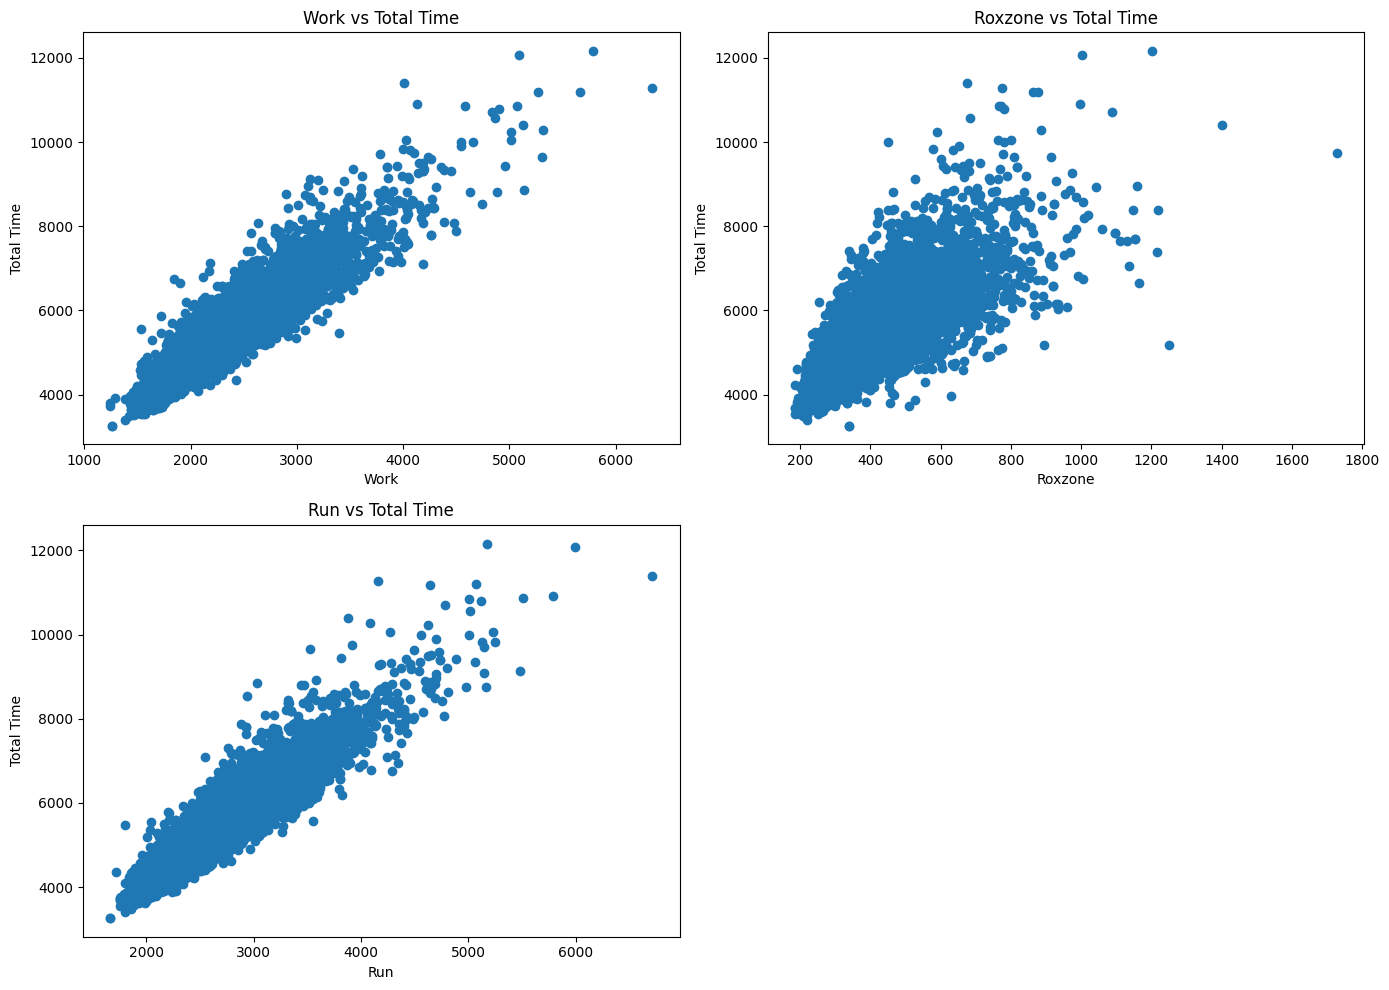

In [8]:
fig, axes = plt.subplots(2,2, figsize=(14,10))

for ax,col in zip(axes[0,:2], segment_order[:2]):
    ax.scatter(df[col], df["total_time_sec"])
    ax.set_xlabel(segment_labels[col])
    ax.set_ylabel("Total Time")
    ax.set_title(f"{segment_labels[col]} vs Total Time")

axes[1,0].scatter(df[segment_order[2]], df["total_time_sec"])
axes[1,0].set_xlabel(segment_labels[segment_order[2]])
axes[1,0].set_ylabel("Total Time")
axes[1,0].set_title("Run vs Total Time")

fig.delaxes(axes[1,1])
plt.tight_layout()
plt.show()

In [9]:
corr_df = df[[
    "work_time_sec",
    "roxzone_time_sec",
    "run_time_sec",
    "total_time_sec"
]].corr()

corr_df.style.background_gradient(cmap="Blues").format("{:.2f}")

,work_time_sec,roxzone_time_sec,run_time_sec,total_time_sec
work_time_sec,1.00,0.60,0.70,0.92
roxzone_time_sec,0.60,1.00,0.66,0.75
run_time_sec,0.70,0.66,1.00,0.92
total_time_sec,0.92,0.75,0.92,1.00


In [10]:
top10_cutoff = df["total_time_sec"].quantile(0.10)

top10 = df[df["total_time_sec"] <= top10_cutoff]
rest = df[df["total_time_sec"] > top10_cutoff]

summary = pd.DataFrame({
    "Top 10%": [
        sec_to_hms(int(top10["work_time_sec"].mean())),
        sec_to_hms(int(top10["roxzone_time_sec"].mean())),
        sec_to_hms(int(top10["run_time_sec"].mean())),
        sec_to_hms(int(top10["total_time_sec"].mean()))
    ],
    "Rest": [
        sec_to_hms(int(rest["work_time_sec"].mean())),
        sec_to_hms(int(rest["roxzone_time_sec"].mean())),
        sec_to_hms(int(rest["run_time_sec"].mean())),
        sec_to_hms(int(rest["total_time_sec"].mean()))
    ],
    "Difference": [
        sec_to_hms(int(rest["work_time_sec"].mean() - top10["work_time_sec"].mean())),
        sec_to_hms(int(rest["roxzone_time_sec"].mean() - top10["roxzone_time_sec"].mean())),
        sec_to_hms(int(rest["run_time_sec"].mean() - top10["run_time_sec"].mean())),
        sec_to_hms(int(rest["total_time_sec"].mean() - top10["total_time_sec"].mean()))
    ]
}, index=["Work","Roxzone","Run","Total"])

summary

,Top 10%,Rest,Difference
Work,0:28:54,0:39:22,0:10:28
Roxzone,0:04:37,0:07:10,0:02:32
Run,0:34:50,0:45:58,0:11:08
Total,1:08:22,1:32:31,0:24:08


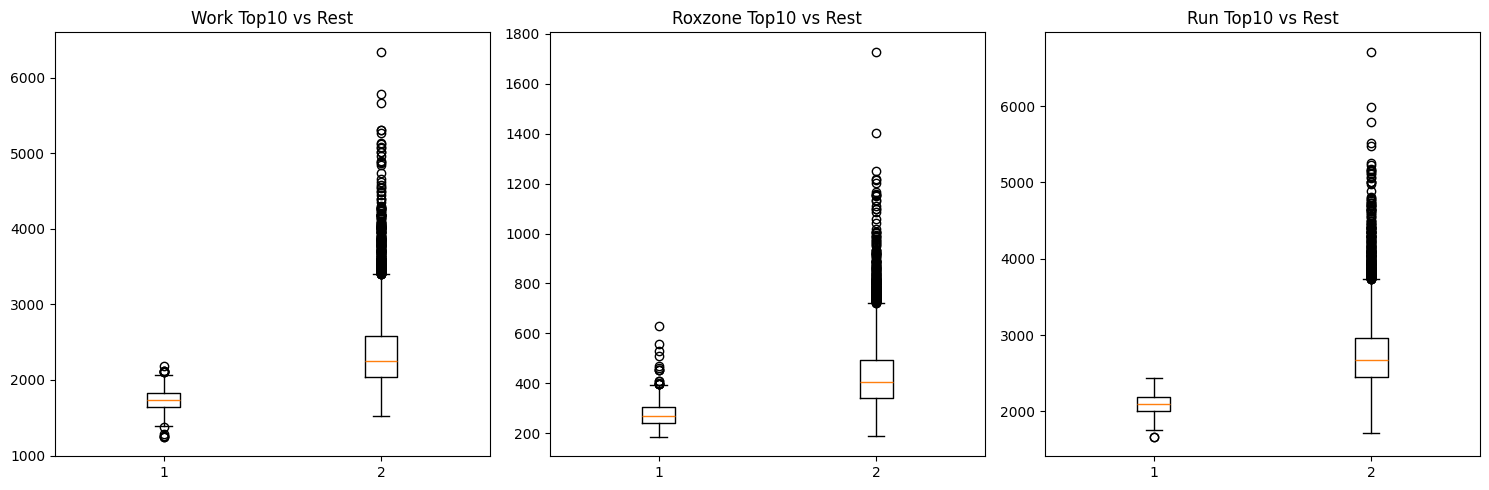

In [11]:
fig2, axes2 = plt.subplots(1,3, figsize=(15,5))

for ax,col in zip(axes2, segment_order):
    ax.boxplot([top10[col], rest[col]])
    ax.set_title(f"{segment_labels[col]} Top10 vs Rest")

plt.tight_layout()
plt.show()

In [12]:
pro = df[df["division"].str.lower() == "pro"]
open_ = df[df["division"].str.lower() == "open"]

pro_open = pd.DataFrame({
    "PRO": [
        sec_to_hms(int(pro["work_time_sec"].mean())),
        sec_to_hms(int(pro["roxzone_time_sec"].mean())),
        sec_to_hms(int(pro["run_time_sec"].mean())),
        sec_to_hms(int(pro["total_time_sec"].mean()))
    ],
    "OPEN": [
        sec_to_hms(int(open_["work_time_sec"].mean())),
        sec_to_hms(int(open_["roxzone_time_sec"].mean())),
        sec_to_hms(int(open_["run_time_sec"].mean())),
        sec_to_hms(int(open_["total_time_sec"].mean()))
    ]
}, index=["Work","Roxzone","Run","Total"])

pro_open

,PRO,OPEN
Work,0:38:37,0:38:16
Roxzone,0:06:00,0:07:03
Run,0:40:32,0:45:33
Total,1:25:09,1:30:53


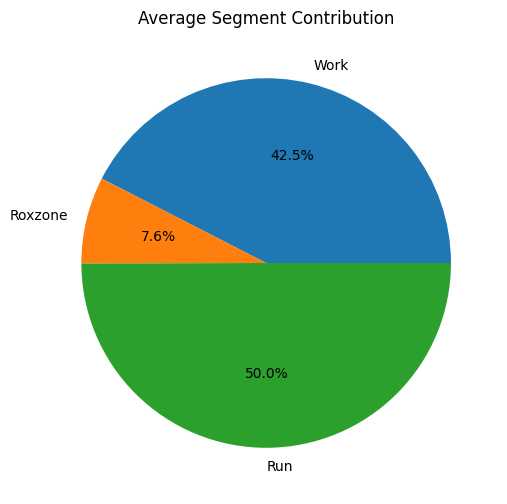

In [13]:
df["work_pct"] = df["work_time_sec"] / df["total_time_sec"] * 100
df["roxzone_pct"] = df["roxzone_time_sec"] / df["total_time_sec"] * 100
df["run_pct"] = df["run_time_sec"] / df["total_time_sec"] * 100

avg_pcts = {
    "Work": df["work_pct"].mean(),
    "Roxzone": df["roxzone_pct"].mean(),
    "Run": df["run_pct"].mean()
}

plt.figure(figsize=(6,6))
plt.pie(avg_pcts.values(), labels=avg_pcts.keys(), autopct="%1.1f%%")
plt.title("Average Segment Contribution")
plt.show()

In [14]:
corr = df[[
    "work_time_sec",
    "roxzone_time_sec",
    "run_time_sec",
    "total_time_sec"
]].corr()["total_time_sec"]

run_corr = corr["run_time_sec"]
work_corr = corr["work_time_sec"]
roxzone_corr = corr["roxzone_time_sec"]

run_pct = df["run_pct"].mean()
work_pct = df["work_pct"].mean()
rox_pct = df["roxzone_pct"].mean()

In [15]:
ideal_times = top10[segment_order].mean()
ideal_total = top10["total_time_sec"].mean()

ideal_df = pd.DataFrame({
    "Average time (Top 10%)": [
        sec_to_hms(int(ideal_times["work_time_sec"])),
        sec_to_hms(int(ideal_times["roxzone_time_sec"])),
        sec_to_hms(int(ideal_times["run_time_sec"])),
        sec_to_hms(int(ideal_total))
    ]
}, index=["Work","Roxzone","Run","Total"])

ideal_df

,Average time (Top 10%)
Work,0:28:54
Roxzone,0:04:37
Run,0:34:50
Total,1:08:22


In [16]:
insights_df = pd.DataFrame({
    "Metric": ["Run impact", "Work impact", "Roxzone impact",
               "Run share", "Work share", "Roxzone share"],
    "Value": [
        f"{run_corr:.2f}",
        f"{work_corr:.2f}",
        f"{roxzone_corr:.2f}",
        f"{run_pct:.1f}%",
        f"{work_pct:.1f}%",
        f"{rox_pct:.1f}%"
    ]
})

insights_df

,Metric,Value
0,Run impact,0.92
1,Work impact,0.92
2,Roxzone impact,0.75
3,Run share,50.0%
4,Work share,42.5%
5,Roxzone share,7.6%


In [17]:
pd.set_option('display.max_colwidth', None)

insights_text = pd.DataFrame({
    "Insight": [
        "Run and Work are the strongest performance drivers",
        "Roxzone has lower influence on final result",
        "Improving Run segment gives highest potential gain"
    ]
})

insights_text.style.set_properties(**{
    'text-align': 'left',
    'white-space': 'pre-wrap'
})

,Insight
0,Run and Work are the strongest performance drivers
1,Roxzone has lower influence on final result
2,Improving Run segment gives highest potential gain
